## Secondary robustness analysis

Evaluates the authentic-only baseline and hybrid transfer-learning model under controlled visual degradations of the held-out test images: low-light reduction, resolution reduction, and centered occlusion, each at two severity levels, plus a clean reference condition. Per-fold accuracy and macro F1 are computed for every (model x condition) combination, then aggregated across folds with mean ± std.

Two plots are produced: an accuracy curve across conditions for both models, and a grouped-bar plot of relative accuracy drop from clean. 

In [5]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score


EVAL_DATA_ROOT = "/content/drive/MyDrive/authentic_split_cv_eval"

M1_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/model1/winner_config6_lr3e-05_lay60_drop0p3_0p6"    #Authentic
M3_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/model3/winner_lr5e-05_lay60_drop0p3_0p6"            #Hybrid

OUTPUT_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/robustness"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["t72", "t80", "t90"]
NUM_FOLDS = 5
IMG_SIZE = (682, 1024)
BATCH_SIZE = 4  

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# Verify each model exists for both regimes before running anything.
for label, d in [("M1", M1_DIR), ("M3", M3_DIR)]:
    for i in range(NUM_FOLDS):
        p = f"{d}/model_fold{i}.keras"
        status = "OK" if os.path.exists(p) else "MISSING"
        print(f"{label} fold {i}: {status}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
M1 fold 0: OK
M1 fold 1: OK
M1 fold 2: OK
M1 fold 3: OK
M1 fold 4: OK
M3 fold 0: OK
M3 fold 1: OK
M3 fold 2: OK
M3 fold 3: OK
M3 fold 4: OK


In [6]:
def degrade_image(image, condition):
    """Apply a visual degradation to a single image tensor."""
    img = tf.cast(image, tf.float32)

    if condition == "clean":
        return img
    elif condition == "lowlight_mild":
        return img * 0.7   # 30% reduction
    elif condition == "lowlight_severe":
        return img * 0.4   # 60% reduction
    elif condition == "resolution_mild":
        h, w = IMG_SIZE
        small = tf.image.resize(img, (h // 2, w // 2), method="bilinear")
        return tf.image.resize(small, (h, w), method="bilinear")
    elif condition == "resolution_severe":
        h, w = IMG_SIZE
        small = tf.image.resize(img, (h // 4, w // 4), method="bilinear")
        return tf.image.resize(small, (h, w), method="bilinear")
    elif condition == "occlusion_mild":
        return apply_occlusion(img, coverage=0.15)
    elif condition == "occlusion_severe":
        return apply_occlusion(img, coverage=0.30)
    else:
        raise ValueError(f"Unknown condition: {condition}")


def apply_occlusion(img, coverage):
    """Cover approximately `coverage` fraction with a centered grey rectangle."""
    h, w = IMG_SIZE
    rect_h = int(h * np.sqrt(coverage))
    rect_w = int(w * np.sqrt(coverage))
    top = (h - rect_h) // 2
    left = (w - rect_w) // 2
    img_np = img.numpy().copy()
    img_np[top:top+rect_h, left:left+rect_w, :] = 128.0  # grey
    return tf.convert_to_tensor(img_np, dtype=tf.float32)


CONDITIONS = [
    "clean",
    "lowlight_mild", "lowlight_severe",
    "resolution_mild", "resolution_severe",
    "occlusion_mild", "occlusion_severe",
]

In [4]:
import gc

def evaluate_model_under_conditions(model_dir, model_label):
    """For one model regime, evaluate all 5 fold-models under all conditions."""
    results = {cond: {"acc": [], "macro_f1": []} for cond in CONDITIONS}

    for fold_idx in range(NUM_FOLDS):
        model_path = f"{model_dir}/model_fold{fold_idx}.keras"
        test_dir = f"{EVAL_DATA_ROOT}/fold_{fold_idx}/test"

        if not os.path.exists(model_path):
            print(f"  MISSING: {model_path}")
            continue

        print(f"  {model_label} fold {fold_idx}: loading model...")
        model = keras.models.load_model(model_path)

        # Load raw test images (unbatched, so each image can be degraded separately)
        raw_ds = keras.utils.image_dataset_from_directory(
            test_dir, labels="inferred", label_mode="int",
            image_size=IMG_SIZE, batch_size=None, shuffle=False,
            crop_to_aspect_ratio=True,
        )

        images, labels = [], []
        for img, lbl in raw_ds:
            images.append(img)
            labels.append(int(lbl.numpy()))
        labels = np.array(labels)

        for cond in CONDITIONS:
            y_pred = []
            for start in range(0, len(images), BATCH_SIZE):
                batch = images[start:start+BATCH_SIZE]
                degraded = tf.stack([degrade_image(im, cond) for im in batch])
                preds = model.predict(degraded, verbose=0)
                y_pred.extend(np.argmax(preds, axis=1))
            y_pred = np.array(y_pred)

            acc = accuracy_score(labels, y_pred)
            mf1 = f1_score(labels, y_pred, average="macro", labels=[0,1,2], zero_division=0)
            results[cond]["acc"].append(acc)
            results[cond]["macro_f1"].append(mf1)

        print(f"    completed all conditions for fold {fold_idx}")
        del model, raw_ds, images, labels
        keras.backend.clear_session()
        gc.collect()

    return results


print("Authentic-only:")
m1_results = evaluate_model_under_conditions(M1_DIR, "Authentic-only")

print("\nHybrid:")
m3_results = evaluate_model_under_conditions(M3_DIR, "Hybrid")

Authentic-only:
  Authentic-only fold 0: loading model...
Found 171 files belonging to 3 classes.
    completed all conditions for fold 0
  Authentic-only fold 1: loading model...
Found 171 files belonging to 3 classes.
    completed all conditions for fold 1
  Authentic-only fold 2: loading model...
Found 172 files belonging to 3 classes.
    completed all conditions for fold 2
  Authentic-only fold 3: loading model...
Found 171 files belonging to 3 classes.
    completed all conditions for fold 3
  Authentic-only fold 4: loading model...
Found 171 files belonging to 3 classes.
    completed all conditions for fold 4

Hybrid:
  Hybrid fold 0: loading model...
Found 171 files belonging to 3 classes.
    completed all conditions for fold 0
  Hybrid fold 1: loading model...
Found 171 files belonging to 3 classes.
    completed all conditions for fold 1
  Hybrid fold 2: loading model...
Found 172 files belonging to 3 classes.
    completed all conditions for fold 2
  Hybrid fold 3: loadin


Authentic-only — mean ± std across 5 folds
Condition           Accuracy              Macro F1              
clean               0.8703 ± 0.0172     0.8539 ± 0.0204
lowlight_mild       0.8703 ± 0.0233     0.8528 ± 0.0296
lowlight_severe     0.8598 ± 0.0221     0.8387 ± 0.0244
resolution_mild     0.8575 ± 0.0223     0.8386 ± 0.0241
resolution_severe   0.8282 ± 0.0285     0.8141 ± 0.0259
occlusion_mild      0.8563 ± 0.0278     0.8342 ± 0.0345
occlusion_severe    0.8131 ± 0.0195     0.7874 ± 0.0246

Hybrid — mean ± std across 5 folds
Condition           Accuracy              Macro F1              
clean               0.8224 ± 0.0573     0.8029 ± 0.0538
lowlight_mild       0.8317 ± 0.0446     0.8126 ± 0.0436
lowlight_severe     0.8306 ± 0.0147     0.8116 ± 0.0170
resolution_mild     0.8271 ± 0.0505     0.8093 ± 0.0526
resolution_severe   0.7979 ± 0.0458     0.7852 ± 0.0435
occlusion_mild      0.8201 ± 0.0330     0.8013 ± 0.0306
occlusion_severe    0.7442 ± 0.0482     0.7140 ± 0.0551

Authe

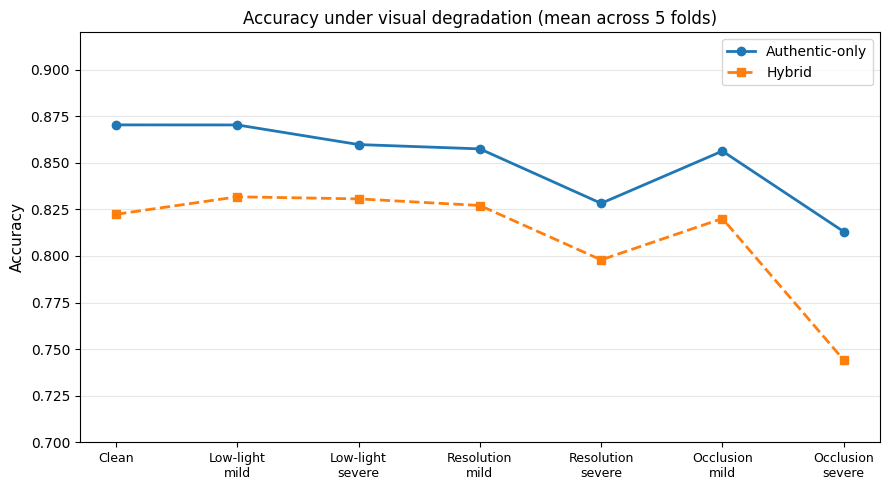

Saved accuracy curve to: /content/drive/MyDrive/authentic_training_cv_eval/robustness/robustness_accuracy_curve.png


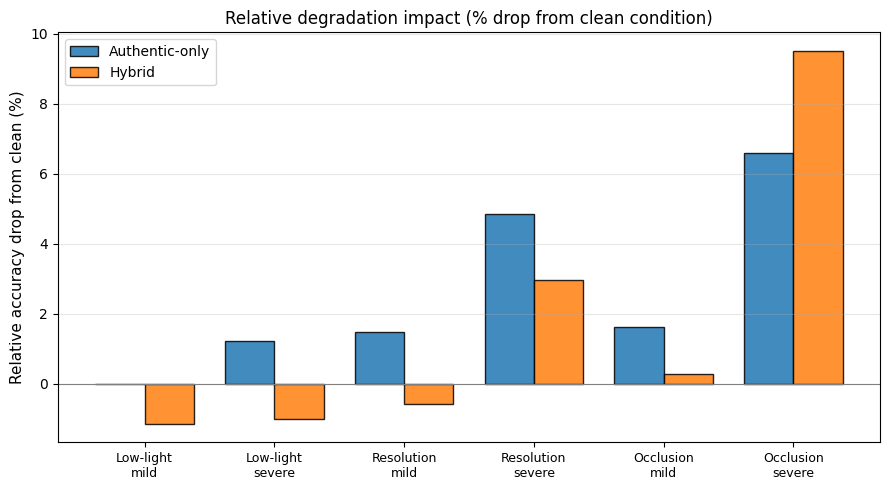

Saved relative drop plot to: /content/drive/MyDrive/authentic_training_cv_eval/robustness/robustness_relative_drop.png


In [7]:
def summarize(results, label):
    """Compute mean ± std (sample) across folds for each condition."""
    print(f"\n{label} — mean ± std across {NUM_FOLDS} folds")
    print(f"{'Condition':<20}{'Accuracy':<22}{'Macro F1':<22}")
    summary = {}
    for cond in CONDITIONS:
        accs = results[cond]["acc"]
        f1s = results[cond]["macro_f1"]
        acc_mean, acc_std = np.mean(accs), np.std(accs, ddof=1)
        f1_mean, f1_std = np.mean(f1s), np.std(f1s, ddof=1)
        print(f"{cond:<20}{acc_mean:.4f} ± {acc_std:.4f}     {f1_mean:.4f} ± {f1_std:.4f}")
        summary[cond] = {
            "acc_mean": acc_mean, "acc_std": acc_std,
            "f1_mean": f1_mean, "f1_std": f1_std,
        }
    return summary


def relative_drops(summary, label):
    """Compute relative accuracy drop from the clean condition for each degradation."""
    print(f"\n{label} — relative accuracy drop from clean:")
    clean = summary["clean"]["acc_mean"]
    drops = {}
    for cond in CONDITIONS:
        if cond == "clean":
            continue
        drop = clean - summary[cond]["acc_mean"]
        rel = (drop / clean) * 100 if clean > 0 else 0
        drops[cond] = rel
        print(f"  {cond:<20} -{drop:.4f}  ({rel:.1f}% relative)")
    return drops


m1_summary = summarize(m1_results, "Authentic-only")
m3_summary = summarize(m3_results, "Hybrid")

m1_drops = relative_drops(m1_summary, "Authentic-only")
m3_drops = relative_drops(m3_summary, "Hybrid")


with open(f"{OUTPUT_DIR}/robustness_results.json", "w") as f:
    json.dump(
        {
            "authentic_only": {"raw": m1_results, "summary": m1_summary},
            "hybrid": {"raw": m3_results, "summary": m3_summary},
        },
        f,
        indent=2,
        default=float,
    )
print(f"\nSaved results to {OUTPUT_DIR}/robustness_results.json")


# Pretty labels for plot ticks. Linebreaks split the severity onto a second
# row so the x-axis doesn't overflow.
cond_labels = {
    "clean": "Clean",
    "lowlight_mild": "Low-light\nmild",
    "lowlight_severe": "Low-light\nsevere",
    "resolution_mild": "Resolution\nmild",
    "resolution_severe": "Resolution\nsevere",
    "occlusion_mild": "Occlusion\nmild",
    "occlusion_severe": "Occlusion\nsevere",
}


# Plot 1: accuracy across conditions, both models on the same axes.
x_labels = [cond_labels[c] for c in CONDITIONS]
x_pos = np.arange(len(CONDITIONS))

m1_acc = [m1_summary[c]["acc_mean"] for c in CONDITIONS]
m3_acc = [m3_summary[c]["acc_mean"] for c in CONDITIONS]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    x_pos, m1_acc,
    marker="o", markersize=6, color="C0", linewidth=2,
    label="Authentic-only",
)
ax.plot(
    x_pos, m3_acc,
    marker="s", markersize=6, color="C1", linewidth=2, linestyle="--",
    label="Hybrid",
)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0.70, 0.92)
ax.set_title("Accuracy under visual degradation (mean across 5 folds)", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
acc_plot_path = f"{OUTPUT_DIR}/robustness_accuracy_curve.png"
plt.savefig(acc_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved accuracy curve to: {acc_plot_path}")


# Plot 2: relative drop from clean, grouped bars per condition.
degraded_conds = [c for c in CONDITIONS if c != "clean"]
x_labels2 = [cond_labels[c] for c in degraded_conds]
x_pos2 = np.arange(len(degraded_conds))
width = 0.38

m1_rel = [m1_drops[c] for c in degraded_conds]
m3_rel = [m3_drops[c] for c in degraded_conds]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x_pos2 - width / 2, m1_rel, width,
    color="C0", edgecolor="black", alpha=0.85,
    label="Authentic-only",
)
ax.bar(
    x_pos2 + width / 2, m3_rel, width,
    color="C1", edgecolor="black", alpha=0.85,
    label="Hybrid",
)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xticks(x_pos2)
ax.set_xticklabels(x_labels2, fontsize=9)
ax.set_ylabel("Relative accuracy drop from clean (%)", fontsize=11)
ax.set_title("Relative degradation impact (% drop from clean condition)", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
drop_plot_path = f"{OUTPUT_DIR}/robustness_relative_drop.png"
plt.savefig(drop_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved relative drop plot to: {drop_plot_path}")